<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [11]</a>'.</span>

## Seasonality

In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches

In [2]:
from dask.distributed import Client
client = Client(n_workers=6, threads_per_worker=3, memory_limit=24e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 18,Total memory: 134.11 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38375,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45207,Total threads: 3
Dashboard: http://127.0.0.1:42521/status,Memory: 22.35 GiB
Nanny: tcp://127.0.0.1:33029,


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D


https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


### Wet and Dry seasons

Precipitation varied seasonally, with a **wet season from mid-December 2000 to July 2001** characterized by successive rainy days, wet soil, and, relative to the dry season, cooler temperatures, greater cloudiness, and reduced incoming solar and net radiation (Rocha et al., 2004)

The seasonal cycle of the near-surface (~5 m below the sea surface) ocean salinity in the APR from multiple ocean-state estimate products shows the **freshest values in May–June–July** and the saltiest in **December–January–February** (Fig. 1d), which largely follows the seasonal cycle of the Amazon river discharge (Fig. 1c). Although the magnitude of the seasonal cycle varies with the chosen datasets, these ocean-state estimate datasets agree that the APR ocean salinity exhibits a similar seasonal evolution to the Amazon river discharge with no apparent lag

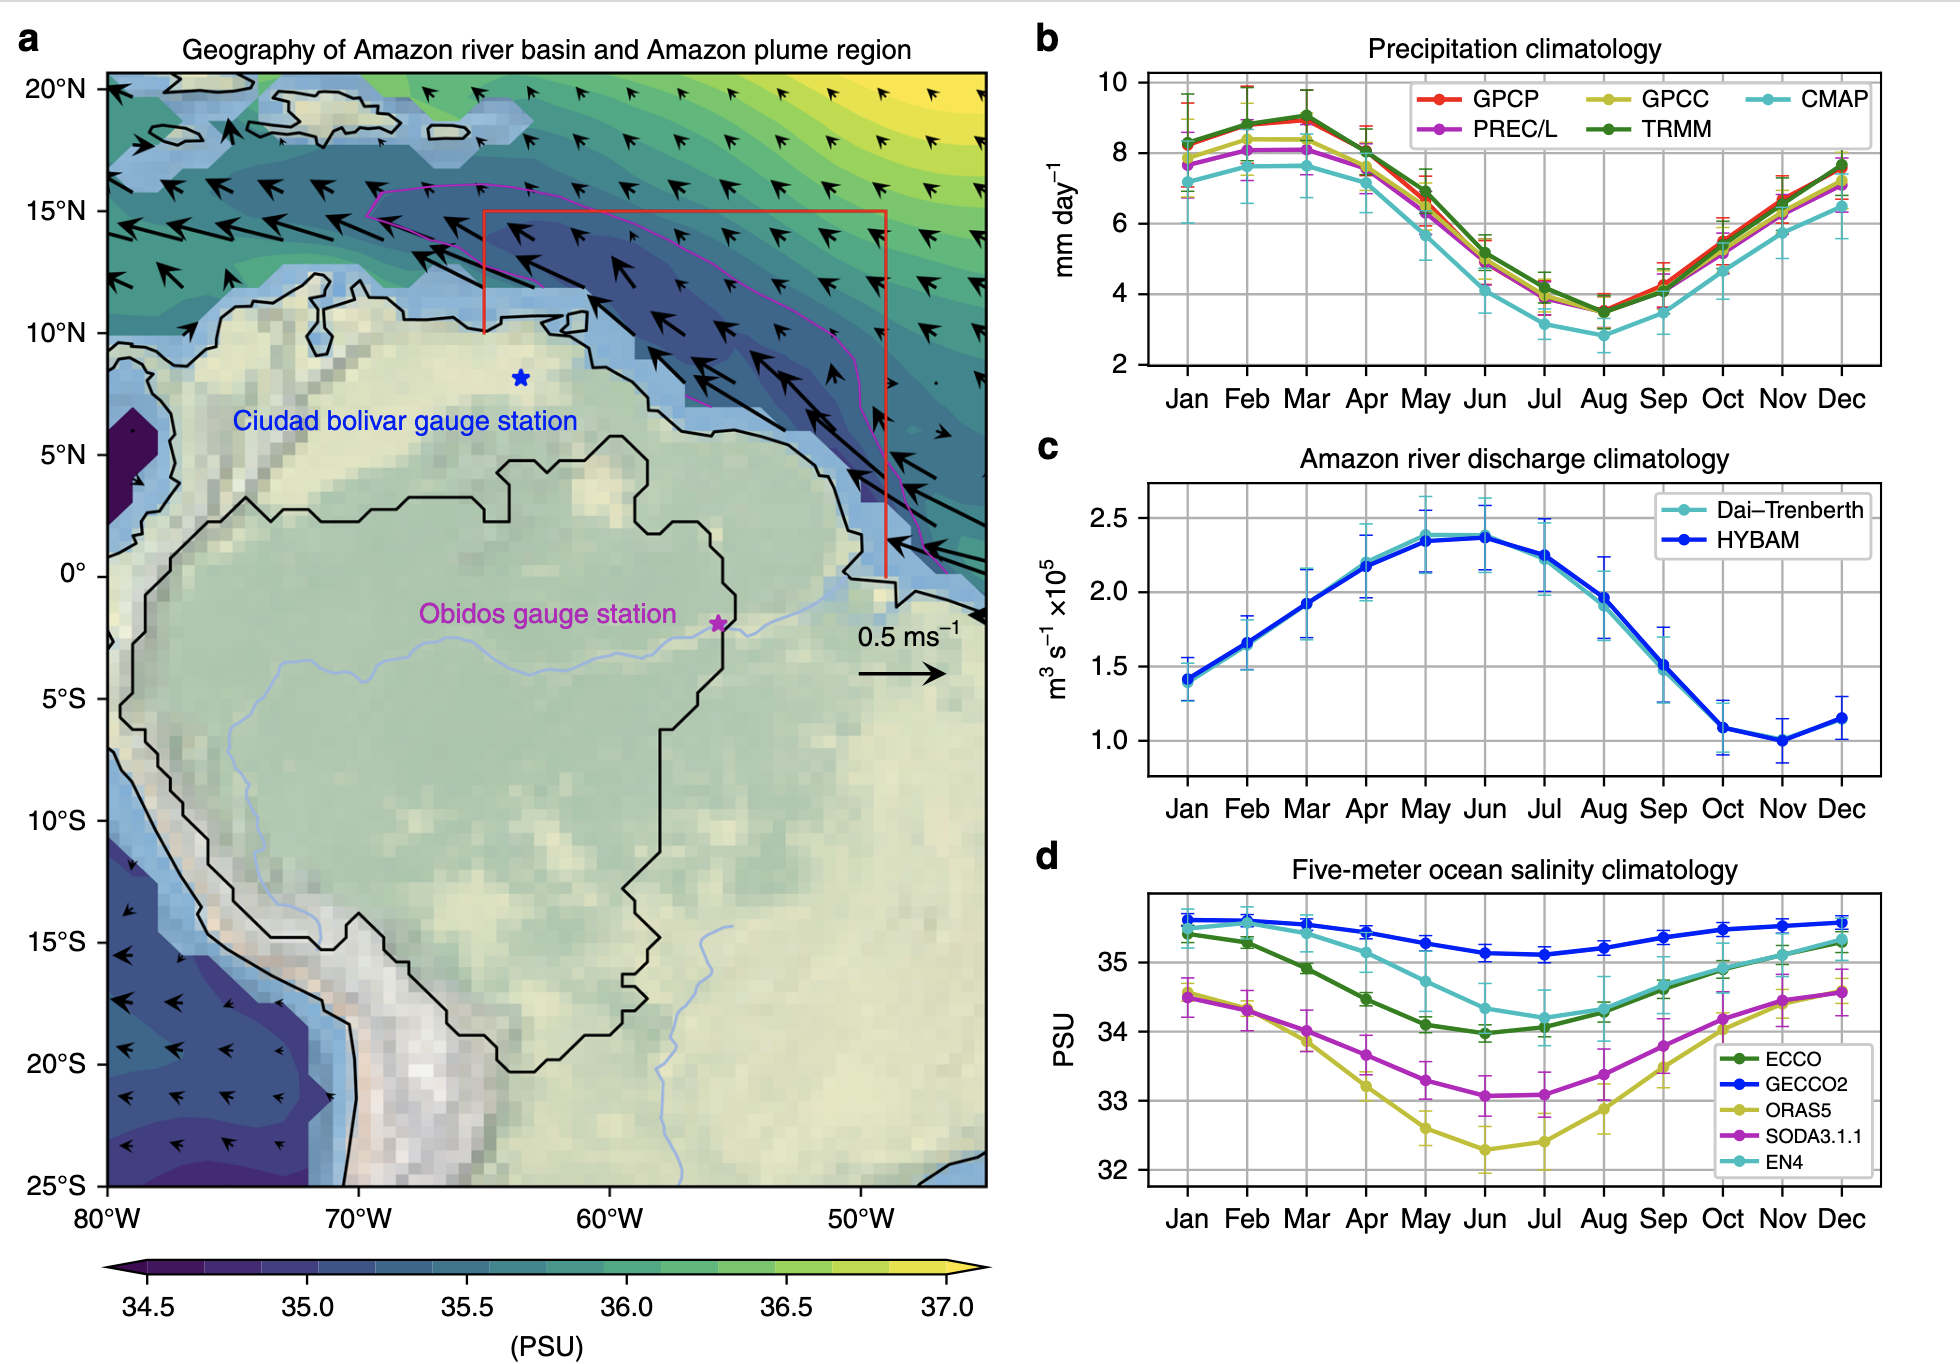

Liang et al., 

In [4]:
hist_month = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/notebooks/seminar/_hist_month.nc").compute().histogram_lon_lat
hist_month

<xarray.DataArray 'histogram_lon_lat' (start_month: 12, obs: 37, lon: 79,
                                       lat: 29)> Size: 8MB
array([[[[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
...
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,   83,    0,    0],
         [   0,    0,    0, ...,  736,  272,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    8,    0,    0],
         [   0,    0,    0, ...,  156,   19,    0],
         [   0,    0,    0, ..., 1216,  262,    8],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]]]],
      shape=(12, 37, 79, 29))
Coordinates:
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


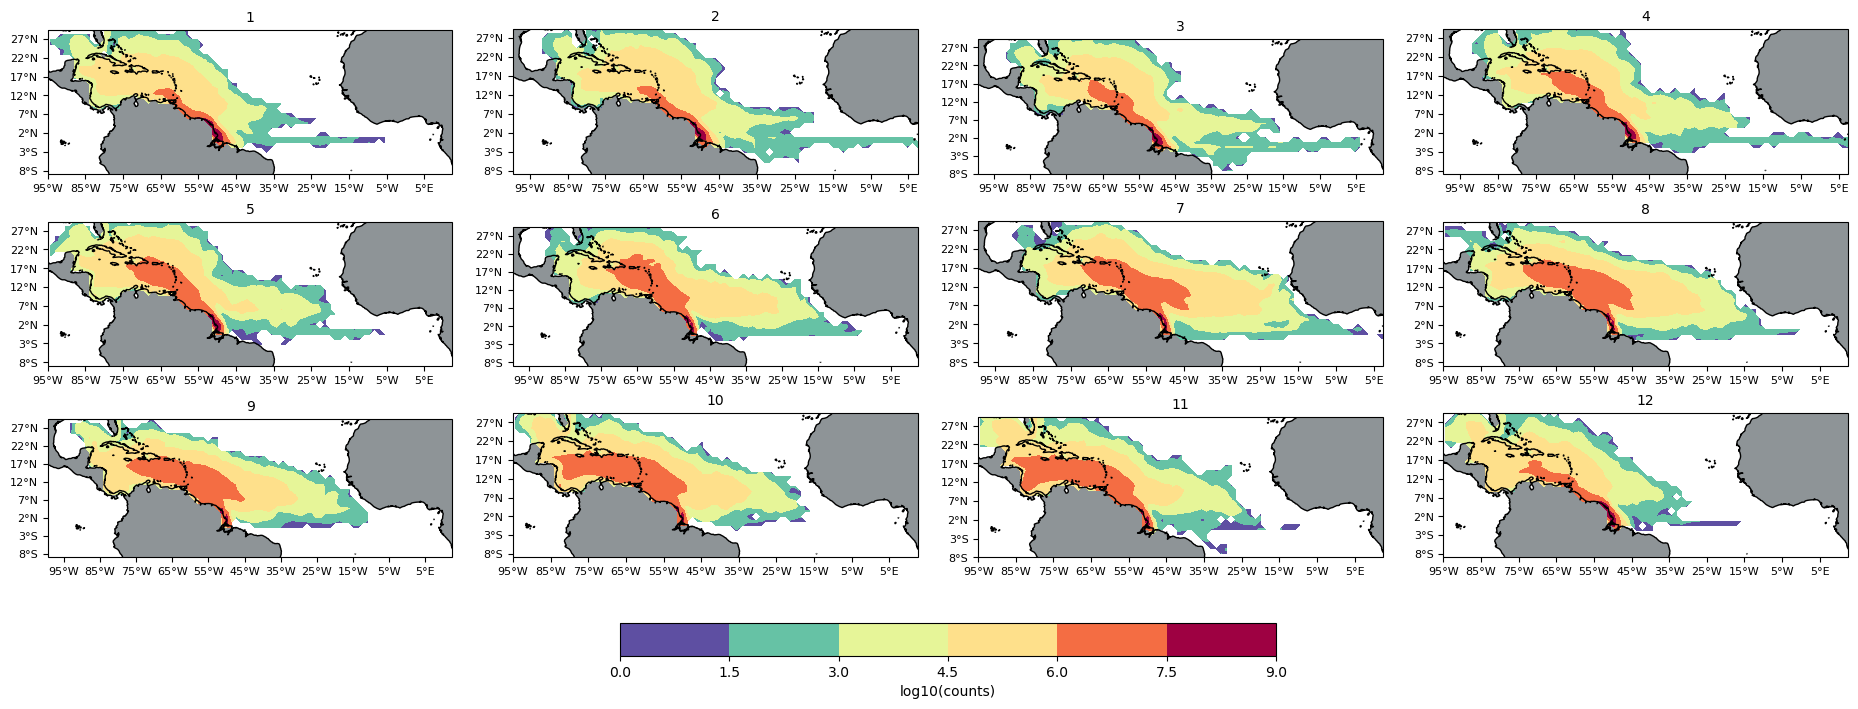

In [5]:
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(
    3, 4,
    figsize=(20, 8),                      # a bit wider, not so tall
    subplot_kw=dict(projection=proj)
)
ax = ax.ravel()

for i in range(12):
    dd = hist_month.sel(start_month=i+1).sum("obs")

    # plot
    pcm = np.log10(dd).plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=proj,
        add_colorbar=False, cmap='Spectral_r'
    )

    ax[i].coastlines()
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_title(i+1, fontsize=10)

    # ticks & labels
    ax[i].set_xticks(
        np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
        crs=proj
    )
    ax[i].set_yticks(
        np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
        crs=proj
    )
    ax[i].xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].tick_params(labelsize=8)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

# Tighter spacing: reduce both wspace and hspace
fig.subplots_adjust(
    left=0.05, right=0.95,
    bottom=0.08, top=0.90,
    wspace=0.15, hspace=0.10
)

# Optional: one shared colorbar at bottom
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10
)
cbar.ax.set_xlabel('log10(counts)', fontsize=10)

plt.show()

In [6]:
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sossheig' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [7]:
U = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc',chunks = {'time_counter':1}).isel(deptht=slice(0,7))
U=U.chunk({'time_counter': 5, 'deptht': 7, 'y': 250, 'x': 600}).rename({'vozocrtx': 'U'})
U

<xarray.Dataset> Size: 140GB
Dimensions:       (time_counter: 7973, deptht: 7, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64kB 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
    nav_lat       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * deptht        (deptht) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
Data variables:
    U             (time_counter, deptht, y, x) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Nov 06 16:54:50 2025: cdo setmissval,nan U_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [8]:
V = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc',chunks = {'time_counter':1}).isel(deptht=slice(0,7))
V=V.chunk({'time_counter': 5, 'deptht': 7, 'y': 250, 'x': 600}).rename({'vomecrty':'V'})
V

<xarray.Dataset> Size: 140GB
Dimensions:       (time_counter: 7973, deptht: 7, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64kB 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
    nav_lat       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * deptht        (deptht) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
Data variables:
    V             (time_counter, deptht, y, x) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:01:55 2025: cdo setmissval,nan V_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [9]:
U_T = (U.U.shift(x=1) + U.U)*0.5

V_T = (V.V.shift(y=1) + V.V)*0.5

In [10]:
UV = xr.Dataset(
    data_vars={
        'U': (('time','depth','lat','lon'), U_T.data),
        'V': (('time','depth','lat', 'lon'), V_T.data),
    },
    coords={
        'time':U_T.time_counter.data,
        'depth':U_T.deptht.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
)
UV['UV'] = (UV.U**2+UV.V**2)**0.5
UV

<xarray.Dataset> Size: 421GB
Dimensions:  (time: 7973, depth: 7, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    U        (time, depth, lat, lon) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>
    V        (time, depth, lat, lon) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>
    UV       (time, depth, lat, lon) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [11]:
uv = UV.UV.mean(dim='depth')
uv = uv.chunk({'time': 10, 'lat': 250, 'lon': 600})
uv = uv.load()
uv.to_netcdf('UV_all_time.nc')

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 130.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


2026-02-04 19:09:56,581 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 181, in __setitem__
    super().__setitem__(key, value)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 193, in __setitem__
    self.fast[key] = value
    ~~~~~~~~~^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/lru.py", line 138, in __setitem__
    self.evict_until_below_target()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/lru.py", line 180, in evict_until_below_target
    self.evict()
  

2026-02-04 19:09:57,136 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 181, in __setitem__
    super().__setitem__(key, value)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 193, in __setitem__
    self.fast[key] = value
    ~~~~~~~~~^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/lru.py", line 138, in __setitem__
    self.evict_until_below_target()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/lru.py", line 180, in evict_until_below_target
    self.evict()
  

2026-02-04 19:09:57,511 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/file.py", line 135, in __setitem__
    fh.writelines(value)
    ~~~~~~~~~~~~~^^^^^^^
OSError: [Errno 28] No space left on device

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 181, in __setitem__
    super().__setitem__(key, value)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 193, in __setitem__
    self.fast[key] = value
    ~~~~~~~~~^^^^^
  File "/work/bk1450/b3831

2026-02-04 19:09:58,830 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/file.py", line 135, in __setitem__
    fh.writelines(value)
    ~~~~~~~~~~~~~^^^^^^^
OSError: [Errno 28] No space left on device

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 181, in __setitem__
    super().__setitem__(key, value)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 193, in __setitem__
    self.fast[key] = value
    ~~~~~~~~~^^^^^
  File "/work/bk1450/b3831

...

2026-02-04 19:12:56,776 - distributed.core - ERROR - Exception while handling op get_data
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 184, in __getitem__
    return self.fast[key]
           ~~~~~~~~~^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/lru.py", line 117, in __getitem__
    result = self.d[key]
             ~~~~~~^^^^^
KeyError: 'original-open_dataset-vozocrtx-99c78018bc033c12e55ba9ce337741be'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/core.py", line 834, in _handle_comm
    result = await result
             ^^^^^^^^^^^^
  File "

2026-02-04 19:12:57,005 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/file.py", line 135, in __setitem__
    fh.writelines(value)
    ~~~~~~~~~~~~~^^^^^^^
OSError: [Errno 28] No space left on device

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/spill.py", line 181, in __setitem__
    super().__setitem__(key, value)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 193, in __setitem__
    self.fast[key] = value
    ~~~~~~~~~^^^^^
  File "/work/bk1450/b3831

2026-02-04 19:12:57,629 - distributed.core - ERROR - Exception while handling op get_data
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 184, in __getitem__
    return self.fast[key]
           ~~~~~~~~~^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/lru.py", line 117, in __getitem__
    result = self.d[key]
             ~~~~~~^^^^^
KeyError: 'original-open_dataset-vomecrty-01e99503f1ee928ba5d719566fb2094b'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/file.py", line 135, in __setitem__
    fh.writelines(value)
    ~~~~~~~~~~~~~^^^^^^^
OSError: [Errno 28

2026-02-04 19:12:57,906 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:45207
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/buffer.py", line 184, in __getitem__
    return self.fast[key]
    ^^^^^^^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
    ^^^^^^^^^^^
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/lru.py", line 117, in __getitem__
    result = self.d[key]
    ^^^^^^^^^^^^^^^
KeyError: 'original-open_dataset-vomecrty-01e99503f1ee928ba5d719566fb2094b'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/zict/file.py", line 135, in __setitem__
    fh.writelines(value)
    ^^^^^^^
OS

OSError: [Errno 28] No space left on device

In [ ]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [ ]:
seasonality(uv).isel(month=1)